[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adaptive-intelligent-robotics/QDax/blob/main/examples/monet.ipynb)

# Multi-task optimization with MONET in JAX

This notebook shows how to use QDax to solve many tasks of the same family simultaneously with [MONET](https://arxiv.org/abs/2604.21991) (Multi-Task Optimization over Networks of Tasks, [reference implementation](https://github.com/ju2ez/MONET)). We run the 10-DoF planar arm benchmark with a parameterized morphology: each of the 5000 tasks is a different morphology (total length of the arm and joint limits) and the goal is to find, for every morphology, the joint angles that bring the end-effector as close as possible to a fixed target, with a budget of 1 million evaluations.

MONET represents the tasks as the nodes of a similarity graph and each node stores the best solution found so far for its task. At every step, a random focal task is selected and, with probability `p_ind`, its elite is mutated (individual learning); otherwise, its elite is crossed-over with the elite of one of its nearest neighbors in the graph (social learning). The offspring is evaluated on the focal task and replaces the elite if its fitness is greater than or equal to the fitness of the elite. This notebook shows:

- how to define a set of tasks and a task-conditioned scoring function
- how to create a MONET instance
- how to launch a certain number of training steps
- how to visualise the resulting map of solutions

## Installation

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [1]:
%pip install -U "jax[cuda]"

/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


Then, install QDax from PyPI:

In [2]:
%pip install -U "qdax[examples]"

/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import functools

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from qdax.core.containers.mapelites_repertoire import compute_cvt_centroids
from qdax.core.monet import MONET
from qdax.tasks.arm import multi_task_arm_scoring_function
from qdax.utils.metrics import default_qd_metrics
from qdax.utils.plotting import plot_map_elites_results

In [4]:
#@title QD Training Definitions Fields
#@markdown ---
seed = 42 #@param {type:"integer"}
num_param_dimensions = 10 #@param {type:"integer"}
num_tasks = 5000 #@param {type:"integer"}
batch_size = 64 #@param {type:"integer"}
num_iterations = 15625 #@param {type:"integer"} # 1 million evaluations
num_init = 500 #@param {type:"integer"} # 10% of the number of tasks
num_neighbors = 50 #@param {type:"integer"} # 1% of the number of tasks
p_ind = 0.5 #@param {type:"number"}
neighbor_strategy = "best_fitness" #@param["best_fitness", "random", "most_similar", "least_similar", "fitness_proportional"]
mutation_std = 0.05 #@param {type:"number"}
num_init_cvt_samples = 50000 #@param {type:"integer"}
min_task_descriptor = 0.0 #@param {type:"number"}
max_task_descriptor = 1.0 #@param {type:"number"}
target = (0.5, 0.5) #@param {type:"raw"}
#@markdown ---

## Define the tasks

A task is a morphology of the arm, described by a 2-dimensional task descriptor: the total length of the arm and the maximum angle of its joints, both normalized. The tasks are spread evenly in the task space with a centroidal Voronoi tessellation, and the task descriptors play the role of the centroids of the repertoire. MONET builds its similarity graph from these descriptors: the neighbors of a task are its `num_neighbors` nearest tasks in descriptor space.

The scoring function evaluates each genotype (the joint angles) on the morphology described by the task descriptor it is given, and returns the negative distance between the end-effector and the target. As in the Multi-task MAP-Elites notebook, we use the target of the reference implementations, (0.5, 0.5).

In [5]:
key = jax.random.key(seed)

# compute the task descriptors (the centroids of the repertoire)
key, subkey = jax.random.split(key)
task_descriptors = compute_cvt_centroids(
    num_descriptors=2,  # (total arm length, max joint angle)
    num_init_cvt_samples=num_init_cvt_samples,
    num_centroids=num_tasks,
    minval=min_task_descriptor,
    maxval=max_task_descriptor,
    key=subkey,
)

# task-conditioned scoring function
scoring_fn = functools.partial(multi_task_arm_scoring_function, target=target)

## Instantiate MONET

MONET uses its own variation pipeline instead of an emitter: individual learning applies a Gaussian mutation to the elite of the focal task, and social learning applies an SBX crossover between the elite of the focal task and the elite of one of its neighbors (by default, the neighbor with the best fitness). These are the default operators of the reference implementation; `individual_learning` and `social_learning` also accept `"polynomial_mutation"` and `"iso_dd"` respectively.

In [6]:
# define a metrics function; the fitness is the negative distance to the
# target, which is bounded below by -(sqrt(2)/2 + 1) in the task space considered
metrics_fn = functools.partial(default_qd_metrics, qd_offset=jnp.sqrt(2) / 2 + 1)

# instantiate MONET
monet = MONET(
    scoring_function=scoring_fn,
    metrics_function=metrics_fn,
    batch_size=batch_size,
    num_neighbors=num_neighbors,
    p_ind=p_ind,
    neighbor_strategy=neighbor_strategy,
    mutation_std=mutation_std,
)

In [7]:
# initial population of random joint angles in [0, 1]
key, subkey = jax.random.split(key)
init_genotypes = jax.random.uniform(
    subkey,
    shape=(num_init, num_param_dimensions),
    minval=0.0,
    maxval=1.0,
)

# initialize the repertoire and the task similarity graph
key, subkey = jax.random.split(key)
repertoire, monet_state, init_metrics = monet.init(
    init_genotypes, task_descriptors, subkey
)

## Launch MONET iterations

In [8]:
(
    repertoire,
    monet_state,
    key,
), metrics = jax.lax.scan(
    monet.scan_update,
    (repertoire, monet_state, key),
    (),
    length=num_iterations,
)

occupied = repertoire.fitnesses[:, 0] != -jnp.inf
print(f"Tasks with a solution: {int(jnp.sum(occupied))} / {num_tasks}")
print(f"Mean fitness over the map: {float(jnp.mean(repertoire.fitnesses[occupied, 0])):.4f}")

Tasks with a solution: 5000 / 5000
Mean fitness over the map: -0.3320


## Visualise the results

The map below shows the fitness of the best solution found for each task: each cell of the map is a morphology of the arm (its total length on the x-axis and its maximum joint angle on the y-axis) and the color is the negative distance between the end-effector and the target. Arms that are long and flexible enough can reach the target exactly, while short arms fall short of it by construction, hence the fitness gradient over the task space.

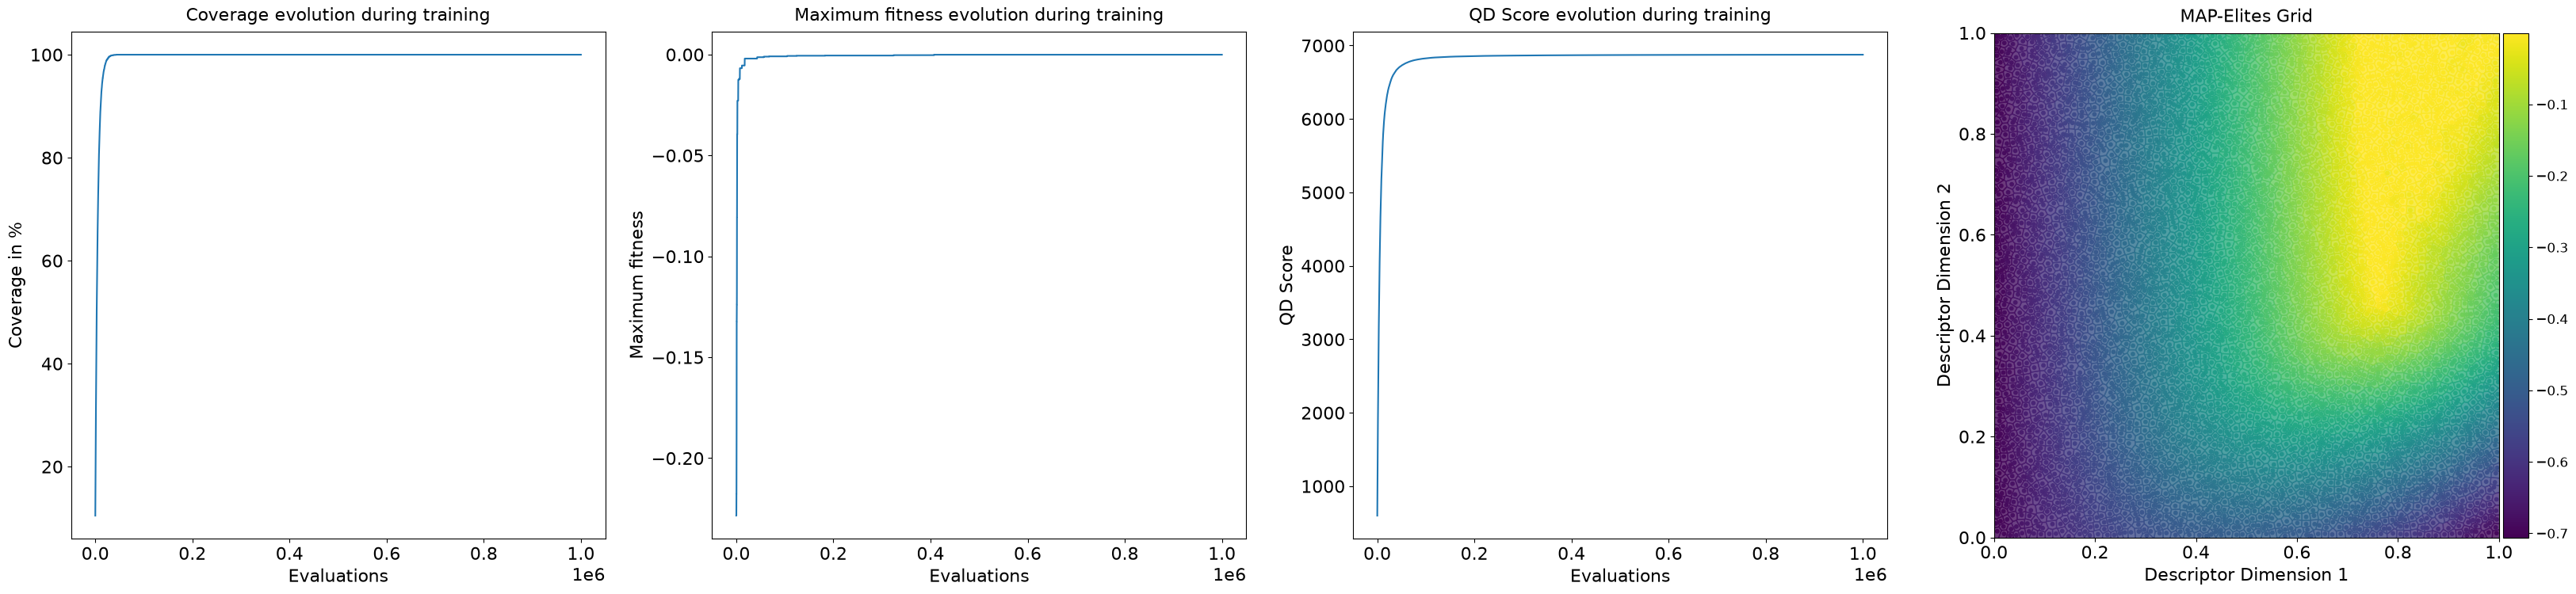

In [ ]:
# create the x-axis array: each iteration evaluates batch_size offsprings
evaluations = jnp.arange(1, num_iterations + 1) * batch_size

# create the plots and the grid
fig, axes = plot_map_elites_results(
    env_steps=evaluations,
    metrics=metrics,
    repertoire=repertoire,
    min_descriptor=min_task_descriptor,
    max_descriptor=max_task_descriptor,
    x_label="Evaluations",
)